
# Thyroid Pathology MIL Patch-Count Ablation — RTX 4060 Notebook

Configured for:

`D:\Thyroid(Laziz)`

This notebook:
1. Checks CUDA / RTX 4060
2. Fixes Mac paths inside the fold CSV
3. Defines the pathology MIL dataset and model
4. Runs patch-count ablation for `3`, `4`, `5`, and `all` cytology patches
5. Runs all 5 folds
6. Exports tables and figures for the manuscript


In [1]:

# =========================================================
# 0. INSTALL PACKAGES IF NEEDED
# =========================================================
# Run only if packages are missing:
#
# !python -m pip install --upgrade pip
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# !pip install timm pandas numpy scikit-learn pillow tqdm matplotlib openpyxl


In [2]:

# =========================================================
# 1. IMPORTS AND CONFIG
# =========================================================
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import timm
import matplotlib.pyplot as plt
from torchvision import transforms

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
)

DATA_ROOT = Path(r"D:\Thyroid(Laziz)")

OLD_ROOT = "/Users/behnamkiani/Downloads/Thyroid"
NEW_ROOT = r"D:\Thyroid(Laziz)"

FOLDS_DIR = DATA_ROOT / "outputs" / "folds"
ORIGINAL_FOLDS_CSV = FOLDS_DIR / "strict_multimodal_5folds.csv"
WINDOWS_FOLDS_CSV = FOLDS_DIR / "strict_multimodal_5folds_windows.csv"

OUTPUT_DIR = DATA_ROOT / "outputs" / "pathology_mil_ablation"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
LOG_DIR = OUTPUT_DIR / "logs"
FIG_DIR = OUTPUT_DIR / "figures"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 16      # If CUDA OOM, reduce to 8
NUM_WORKERS = 0      # If DataLoader hangs on Windows/Jupyter, set to 0
EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 1e-4
RANDOM_SEED = 42
MODEL_NAME = "resnet18"

FOLDS = [0, 1, 2, 3, 4]
BAG_SIZES = ["3", "4", "5", "all"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DATA_ROOT:", DATA_ROOT)
print("DEVICE:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)


DATA_ROOT: D:\Thyroid(Laziz)
DEVICE: cuda
GPU: NVIDIA GeForce RTX 4060
CUDA version: 12.1


In [3]:

# =========================================================
# 2. CUDA CHECK
# =========================================================
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    x = torch.randn(2, 3).cuda()
    print("CUDA tensor test:", x.device, x.shape)
else:
    print("CUDA is not available. Training will run on CPU.")


Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4060
CUDA tensor test: cuda:0 torch.Size([2, 3])


In [4]:

# =========================================================
# 3. FIX CSV PATHS FROM MAC TO WINDOWS
# =========================================================
def fix_windows_paths():
    if not ORIGINAL_FOLDS_CSV.exists():
        raise FileNotFoundError(f"Original fold CSV not found: {ORIGINAL_FOLDS_CSV}")

    df = pd.read_csv(ORIGINAL_FOLDS_CSV)

    path_cols = [
        "ultrasound_image_path",
        "all_ultrasound_paths_json",
        "pathology_patch_paths_json",
    ]

    for col in path_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace(
                OLD_ROOT,
                NEW_ROOT.replace("\\", "\\\\"),
                regex=False
            )

    df.to_csv(WINDOWS_FOLDS_CSV, index=False)
    print("Saved:", WINDOWS_FOLDS_CSV)
    return df

df_folds = fix_windows_paths()
df_folds.head()


Saved: D:\Thyroid(Laziz)\outputs\folds\strict_multimodal_5folds_windows.csv


,patient_id,base_id,label_name,label,num_ultrasound_images,ultrasound_image_path,all_ultrasound_paths_json,num_patches,pathology_patch_paths_json,has_ultrasound,exactly_one_ultrasound,patch_count_ok,valid_pair,fold
0,benign_1,1,benign,0,1,D:\\Thyroid(Laziz)/Ultrasound images of benign...,"[""D:\\Thyroid(Laziz)/Ultrasound images of beni...",3,"[""D:\\Thyroid(Laziz)/Cytological images of ben...",True,True,True,True,4
1,benign_10,10,benign,0,1,D:\\Thyroid(Laziz)/Ultrasound images of benign...,"[""D:\\Thyroid(Laziz)/Ultrasound images of beni...",3,"[""D:\\Thyroid(Laziz)/Cytological images of ben...",True,True,True,True,1
2,benign_100,100,benign,0,1,D:\\Thyroid(Laziz)/Ultrasound images of benign...,"[""D:\\Thyroid(Laziz)/Ultrasound images of beni...",4,"[""D:\\Thyroid(Laziz)/Cytological images of ben...",True,True,True,True,4
3,benign_101,101,benign,0,1,D:\\Thyroid(Laziz)/Ultrasound images of benign...,"[""D:\\Thyroid(Laziz)/Ultrasound images of beni...",3,"[""D:\\Thyroid(Laziz)/Cytological images of ben...",True,True,True,True,4
4,benign_102,102,benign,0,1,D:\\Thyroid(Laziz)/Ultrasound images of benign...,"[""D:\\Thyroid(Laziz)/Ultrasound images of beni...",3,"[""D:\\Thyroid(Laziz)/Cytological images of ben...",True,True,True,True,2


In [5]:

# =========================================================
# 4. DATA CHECK
# =========================================================
df = pd.read_csv(WINDOWS_FOLDS_CSV)

print("Total patients:", len(df))
print("\nLabel counts:")
print(df["label_name"].value_counts())

print("\nFold counts:")
print(df.groupby(["fold", "label_name"]).size())

sample_us = Path(df.iloc[0]["ultrasound_image_path"])
sample_patches = json.loads(df.iloc[0]["pathology_patch_paths_json"])

print("\nSample ultrasound:", sample_us)
print("Exists:", sample_us.exists())

print("\nSample pathology patch:", sample_patches[0])
print("Exists:", Path(sample_patches[0]).exists())


Total patients: 368

Label counts:
label_name
ptc       210
benign    158
Name: count, dtype: int64

Fold counts:
fold  label_name
0     benign        32
      ptc           42
1     benign        32
      ptc           42
2     benign        32
      ptc           42
3     benign        31
      ptc           42
4     benign        31
      ptc           42
dtype: int64

Sample ultrasound: D:\Thyroid(Laziz)\Ultrasound images of benign thyroid lesions\1.jpg
Exists: True

Sample pathology patch: D:\Thyroid(Laziz)/Cytological images of benign thyroid lesions/1_001.tif
Exists: True


In [6]:

# =========================================================
# 5. REPRODUCIBILITY
# =========================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(RANDOM_SEED)


In [7]:

# =========================================================
# 6. DATASET AND TRANSFORMS
# =========================================================
def pil_loader(path: str):
    return Image.open(path).convert("RGB")


def parse_json_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    return json.loads(x)


def get_pathology_train_transform(img_size=224):
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=90),
        transforms.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.08),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])


def get_pathology_val_transform(img_size=224):
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])


def load_fold_dataframe(folds_csv_path, fold, split):
    df = pd.read_csv(folds_csv_path)

    if split == "train":
        df = df[df["fold"] != fold].copy()
    elif split == "val":
        df = df[df["fold"] == fold].copy()
    else:
        raise ValueError("split must be train or val")

    return df.reset_index(drop=True)


class PathologyBagsDataset(Dataset):
    def __init__(self, folds_csv_path, fold, split, img_size=224, bag_size=None, sample_strategy="random"):
        self.df = load_fold_dataframe(folds_csv_path, fold, split)
        self.df = self.df[self.df["num_patches"] >= 1].reset_index(drop=True)

        self.transform = (
            get_pathology_train_transform(img_size)
            if split == "train"
            else get_pathology_val_transform(img_size)
        )

        self.bag_size = bag_size
        self.sample_strategy = sample_strategy
        self.split = split

    def __len__(self):
        return len(self.df)

    def _choose_patch_paths(self, patch_paths):
        if self.bag_size is None:
            return patch_paths

        n = len(patch_paths)

        if n >= self.bag_size:
            if self.sample_strategy == "random" and self.split == "train":
                return random.sample(patch_paths, self.bag_size)
            return patch_paths[:self.bag_size]

        chosen = patch_paths.copy()
        while len(chosen) < self.bag_size:
            if self.sample_strategy == "random" and self.split == "train":
                chosen.append(random.choice(patch_paths))
            else:
                chosen.append(patch_paths[len(chosen) % n])

        return chosen

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        patch_paths = parse_json_list(row["pathology_patch_paths_json"])
        patch_paths = self._choose_patch_paths(patch_paths)

        bag = []
        for p in patch_paths:
            img = pil_loader(p)
            img = self.transform(img)
            bag.append(img)

        bag = torch.stack(bag, dim=0)
        label = torch.tensor(int(row["label"]), dtype=torch.float32)

        return {
            "bag": bag,
            "bag_length": torch.tensor(len(patch_paths), dtype=torch.long),
            "label": label,
            "patient_id": row["patient_id"],
        }


def pathology_bag_collate_fn(batch):
    labels = torch.stack([x["label"] for x in batch], dim=0)
    patient_ids = [x["patient_id"] for x in batch]

    bag_lengths = torch.tensor([x["bag"].shape[0] for x in batch], dtype=torch.long)
    max_len = int(bag_lengths.max().item())

    c, h, w = batch[0]["bag"].shape[1:]

    padded_bags = []
    bag_masks = []

    for x in batch:
        bag = x["bag"]
        n = bag.shape[0]

        if n < max_len:
            pad = torch.zeros((max_len - n, c, h, w), dtype=bag.dtype)
            bag = torch.cat([bag, pad], dim=0)

        mask = torch.zeros(max_len, dtype=torch.bool)
        mask[:n] = True

        padded_bags.append(bag)
        bag_masks.append(mask)

    return {
        "bag": torch.stack(padded_bags, dim=0),
        "bag_mask": torch.stack(bag_masks, dim=0),
        "bag_length": bag_lengths,
        "label": labels,
        "patient_id": patient_ids,
    }


In [8]:

# =========================================================
# 7. DATASET TEST
# =========================================================
test_ds = PathologyBagsDataset(
    folds_csv_path=str(WINDOWS_FOLDS_CSV),
    fold=0,
    split="train",
    img_size=IMG_SIZE,
    bag_size=3
)

test_loader = DataLoader(
    test_ds,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    collate_fn=pathology_bag_collate_fn
)

batch = next(iter(test_loader))
print("Dataset length:", len(test_ds))
print("Bag batch shape:", batch["bag"].shape)
print("Mask shape:", batch["bag_mask"].shape)
print("Labels:", batch["label"])
print("Patient IDs:", batch["patient_id"][:4])


Dataset length: 294
Bag batch shape: torch.Size([4, 3, 3, 224, 224])
Mask shape: torch.Size([4, 3])
Labels: tensor([0., 1., 1., 1.])
Patient IDs: ['benign_127', 'ptc_172', 'ptc_162', 'ptc_124']


In [9]:

# =========================================================
# 8. METRICS
# =========================================================
def safe_auc(y_true, y_prob):
    try:
        return roc_auc_score(y_true, y_prob)
    except Exception:
        return float("nan")


def safe_auprc(y_true, y_prob):
    try:
        return average_precision_score(y_true, y_prob)
    except Exception:
        return float("nan")


def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    auc_val = safe_auc(y_true, y_prob)
    auprc = safe_auprc(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        mcc = matthews_corrcoef(y_true, y_pred)
    except Exception:
        mcc = float("nan")

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    return {
        "auroc": auc_val,
        "auprc": auprc,
        "accuracy": acc,
        "f1": f1,
        "mcc": mcc,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


In [10]:

# =========================================================
# 9. MODEL
# =========================================================
class PatchEncoder(nn.Module):
    def __init__(self, model_name="resnet18", pretrained=True, feat_dim=256):
        super().__init__()

        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,
            global_pool="avg"
        )

        in_dim = self.backbone.num_features

        self.proj = nn.Sequential(
            nn.Linear(in_dim, feat_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25)
        )

    def forward(self, x):
        return self.proj(self.backbone(x))


class AttentionMIL(nn.Module):
    def __init__(self, model_name="resnet18", pretrained=True, feat_dim=256, attn_dim=128):
        super().__init__()

        self.encoder = PatchEncoder(
            model_name=model_name,
            pretrained=pretrained,
            feat_dim=feat_dim
        )

        self.attn_v = nn.Linear(feat_dim, attn_dim)
        self.attn_u = nn.Linear(feat_dim, attn_dim)
        self.attn_w = nn.Linear(attn_dim, 1)

        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(128, 1)
        )

    def forward(self, bag, bag_mask):
        B, N, C, H, W = bag.shape

        flat = bag.view(B * N, C, H, W)
        feat = self.encoder(flat)

        D = feat.shape[-1]
        feat = feat.view(B, N, D)

        A_v = torch.tanh(self.attn_v(feat))
        A_u = torch.sigmoid(self.attn_u(feat))
        A = self.attn_w(A_v * A_u).squeeze(-1)

        A = A.masked_fill(~bag_mask, float("-inf"))
        attn = torch.softmax(A, dim=1)

        bag_feat = torch.sum(attn.unsqueeze(-1) * feat, dim=1)
        logits = self.classifier(bag_feat).squeeze(-1)

        return logits, attn


In [11]:

# =========================================================
# 10. TRAIN / EVAL
# =========================================================
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    all_probs = []
    all_labels = []

    for batch in tqdm(loader, desc="Train", leave=False):
        bag = batch["bag"].to(device, non_blocking=True)
        bag_mask = batch["bag_mask"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad()

        logits, _ = model(bag, bag_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        labs = labels.detach().cpu().numpy()

        running_loss += loss.item() * bag.size(0)
        all_probs.extend(probs.tolist())
        all_labels.extend(labs.tolist())

    metrics = compute_binary_metrics(all_labels, all_probs)
    metrics["loss"] = running_loss / len(loader.dataset)

    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_probs = []
    all_labels = []
    all_patient_ids = []

    for batch in tqdm(loader, desc="Val", leave=False):
        bag = batch["bag"].to(device, non_blocking=True)
        bag_mask = batch["bag_mask"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        logits, _ = model(bag, bag_mask)
        loss = criterion(logits, labels)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        labs = labels.detach().cpu().numpy()

        running_loss += loss.item() * bag.size(0)
        all_probs.extend(probs.tolist())
        all_labels.extend(labs.tolist())
        all_patient_ids.extend(batch["patient_id"])

    metrics = compute_binary_metrics(all_labels, all_probs)
    metrics["loss"] = running_loss / len(loader.dataset)

    predictions = {
        "patient_id": all_patient_ids,
        "y_true": [int(x) for x in all_labels],
        "y_prob": [float(x) for x in all_probs],
    }

    return metrics, predictions


In [12]:

# =========================================================
# 11. RUN ONE EXPERIMENT
# =========================================================
def run_one_experiment(fold, bag_size_label):
    seed_everything(RANDOM_SEED)

    bag_size = None if bag_size_label == "all" else int(bag_size_label)
    bag_tag = "all" if bag_size is None else f"bag{bag_size}"

    print("\n" + "=" * 80)
    print(f"PATHOLOGY MIL PATCH-COUNT ABLATION | Fold={fold} | Bag={bag_size_label}")
    print("=" * 80)
    print("Device:", DEVICE)

    train_ds = PathologyBagsDataset(
        folds_csv_path=str(WINDOWS_FOLDS_CSV),
        fold=fold,
        split="train",
        img_size=IMG_SIZE,
        bag_size=bag_size
    )

    val_ds = PathologyBagsDataset(
        folds_csv_path=str(WINDOWS_FOLDS_CSV),
        fold=fold,
        split="val",
        img_size=IMG_SIZE,
        bag_size=bag_size
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=pathology_bag_collate_fn,
        persistent_workers=(NUM_WORKERS > 0),
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=pathology_bag_collate_fn,
        persistent_workers=(NUM_WORKERS > 0),
    )

    train_df = train_ds.df
    n_neg = int((train_df["label"] == 0).sum())
    n_pos = int((train_df["label"] == 1).sum())

    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(DEVICE)

    print(f"Train size: {len(train_ds)} | Val size: {len(val_ds)}")
    print(f"Train negatives: {n_neg} | Train positives: {n_pos}")
    print(f"pos_weight: {pos_weight.item():.4f}")

    model = AttentionMIL(
        model_name=MODEL_NAME,
        pretrained=True,
        feat_dim=256,
        attn_dim=128
    ).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS
    )

    best_auroc = -1.0
    history = []
    best_preds = None

    for epoch in range(1, EPOCHS + 1):
        print(f"\nEpoch {epoch}/{EPOCHS}")

        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_metrics, val_preds = evaluate(model, val_loader, criterion, DEVICE)

        scheduler.step()

        row = {
            "epoch": epoch,
            "fold": fold,
            "bag_size": bag_size_label,
            "bag_tag": bag_tag,

            "train_loss": train_metrics["loss"],
            "train_auroc": train_metrics["auroc"],
            "train_auprc": train_metrics["auprc"],
            "train_accuracy": train_metrics["accuracy"],
            "train_f1": train_metrics["f1"],
            "train_mcc": train_metrics["mcc"],
            "train_sensitivity": train_metrics["sensitivity"],
            "train_specificity": train_metrics["specificity"],

            "val_loss": val_metrics["loss"],
            "val_auroc": val_metrics["auroc"],
            "val_auprc": val_metrics["auprc"],
            "val_accuracy": val_metrics["accuracy"],
            "val_f1": val_metrics["f1"],
            "val_mcc": val_metrics["mcc"],
            "val_sensitivity": val_metrics["sensitivity"],
            "val_specificity": val_metrics["specificity"],
        }

        history.append(row)

        print(
            f"Train loss={train_metrics['loss']:.4f} | "
            f"AUROC={train_metrics['auroc']:.4f} | "
            f"AUPRC={train_metrics['auprc']:.4f}"
        )

        print(
            f"Val   loss={val_metrics['loss']:.4f} | "
            f"AUROC={val_metrics['auroc']:.4f} | "
            f"AUPRC={val_metrics['auprc']:.4f} | "
            f"ACC={val_metrics['accuracy']:.4f} | "
            f"Sens={val_metrics['sensitivity']:.4f} | "
            f"Spec={val_metrics['specificity']:.4f}"
        )

        if val_metrics["auroc"] > best_auroc:
            best_auroc = val_metrics["auroc"]
            best_preds = val_preds

            ckpt_path = CHECKPOINT_DIR / f"best_fold{fold}_{MODEL_NAME}_attnmil_{bag_tag}.pt"

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_auroc": best_auroc,
                    "fold": fold,
                    "bag_size": bag_size_label,
                    "bag_tag": bag_tag,
                    "config": {
                        "img_size": IMG_SIZE,
                        "batch_size": BATCH_SIZE,
                        "lr": LR,
                        "weight_decay": WEIGHT_DECAY,
                        "model_name": MODEL_NAME,
                    }
                },
                ckpt_path
            )

            pred_path = LOG_DIR / f"best_val_predictions_fold{fold}_{MODEL_NAME}_attnmil_{bag_tag}.csv"
            pd.DataFrame(best_preds).to_csv(pred_path, index=False)

            print("Saved best checkpoint:", ckpt_path)

    history_df = pd.DataFrame(history)

    history_csv = LOG_DIR / f"history_fold{fold}_{MODEL_NAME}_attnmil_{bag_tag}.csv"
    history_df.to_csv(history_csv, index=False)

    best_idx = history_df["val_auroc"].idxmax()

    summary = {
        "fold": fold,
        "bag_size": bag_size_label,
        "bag_tag": bag_tag,
        "model_name": MODEL_NAME,
        "device": DEVICE,
        "train_size": len(train_ds),
        "val_size": len(val_ds),

        "best_epoch_by_auroc": int(history_df.loc[best_idx, "epoch"]),
        "best_val_auroc": float(history_df.loc[best_idx, "val_auroc"]),
        "best_val_auprc": float(history_df.loc[best_idx, "val_auprc"]),
        "best_val_accuracy": float(history_df.loc[best_idx, "val_accuracy"]),
        "best_val_f1": float(history_df.loc[best_idx, "val_f1"]),
        "best_val_mcc": float(history_df.loc[best_idx, "val_mcc"]),
        "best_val_sensitivity": float(history_df.loc[best_idx, "val_sensitivity"]),
        "best_val_specificity": float(history_df.loc[best_idx, "val_specificity"]),
    }

    summary_path = LOG_DIR / f"summary_fold{fold}_{MODEL_NAME}_attnmil_{bag_tag}.json"

    with open(summary_path, "w") as f:
        json.dump(summary, f, indent=2)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("\nTRAINING COMPLETE")
    print(json.dumps(summary, indent=2))
    print("Saved history:", history_csv)
    print("Saved summary:", summary_path)

    return summary


In [13]:

# =========================================================
# 12. QUICK SINGLE TEST RUN
# =========================================================
# Run this cell first. If it works and says Device: cuda,
# continue to the full ablation cell.
#
# test_summary = run_one_experiment(fold=0, bag_size_label="3")
# test_summary


In [14]:

# =========================================================
# 13. FULL PATCH-COUNT ABLATION
# =========================================================
# This runs 20 trainings:
# bag sizes: 3, 4, 5, all
# folds: 0, 1, 2, 3, 4

all_summaries = []

for bag_size_label in BAG_SIZES:
    for fold in FOLDS:
        summary = run_one_experiment(fold=fold, bag_size_label=bag_size_label)
        all_summaries.append(summary)

all_results_df = pd.DataFrame(all_summaries)
all_results_csv = LOG_DIR / "patch_count_ablation_all_folds.csv"
all_results_df.to_csv(all_results_csv, index=False)

print("Saved all fold results to:", all_results_csv)
all_results_df



PATHOLOGY MIL PATCH-COUNT ABLATION | Fold=0 | Bag=3
Device: cuda
Train size: 294 | Val size: 74
Train negatives: 126 | Train positives: 168
pos_weight: 0.7500

Epoch 1/20


Train:   0%|          | 0/19 [00:00<?, ?it/s]

Val:   0%|          | 0/5 [00:00<?, ?it/s]

Train loss=0.5910 | AUROC=0.6690 | AUPRC=0.7423
Val   loss=0.5832 | AUROC=0.9293 | AUPRC=0.9530 | ACC=0.5676 | Sens=1.0000 | Spec=0.0000
Saved best checkpoint: D:\Thyroid(Laziz)\outputs\pathology_mil_ablation\checkpoints\best_fold0_resnet18_attnmil_bag3.pt

Epoch 2/20


Train:   0%|          | 0/19 [00:00<?, ?it/s]

...

Train loss=0.1210 | AUROC=0.9888 | AUPRC=0.9927
Val   loss=0.1250 | AUROC=0.9877 | AUPRC=0.9912 | ACC=0.9726 | Sens=0.9762 | Spec=0.9677

Epoch 20/20


Train:   0%|          | 0/19 [00:00<?, ?it/s]

Val:   0%|          | 0/5 [00:00<?, ?it/s]

Train loss=0.1695 | AUROC=0.9752 | AUPRC=0.9826
Val   loss=0.1239 | AUROC=0.9877 | AUPRC=0.9912 | ACC=0.9726 | Sens=0.9762 | Spec=0.9677

TRAINING COMPLETE
{
  "fold": 4,
  "bag_size": "all",
  "bag_tag": "all",
  "model_name": "resnet18",
  "device": "cuda",
  "train_size": 295,
  "val_size": 73,
  "best_epoch_by_auroc": 15,
  "best_val_auroc": 0.988479262672811,
  "best_val_auprc": 0.9916335724033322,
  "best_val_accuracy": 0.9726027397260274,
  "best_val_f1": 0.9761904761904762,
  "best_val_mcc": 0.9439324116743472,
  "best_val_sensitivity": 0.9761904761904762,
  "best_val_specificity": 0.967741935483871
}
Saved history: D:\Thyroid(Laziz)\outputs\pathology_mil_ablation\logs\history_fold4_resnet18_attnmil_all.csv
Saved summary: D:\Thyroid(Laziz)\outputs\pathology_mil_ablation\logs\summary_fold4_resnet18_attnmil_all.json
Saved all fold results to: D:\Thyroid(Laziz)\outputs\pathology_mil_ablation\logs\patch_count_ablation_all_folds.csv


,fold,bag_size,bag_tag,model_name,device,train_size,val_size,best_epoch_by_auroc,best_val_auroc,best_val_auprc,best_val_accuracy,best_val_f1,best_val_mcc,best_val_sensitivity,best_val_specificity
0,0,3,bag3,resnet18,cuda,294,74,19,0.960565,0.969964,0.905405,0.915663,0.808310,0.904762,0.906250
1,1,3,bag3,resnet18,cuda,294,74,18,0.956845,0.970164,0.932432,0.941176,0.862166,0.952381,0.906250
2,2,3,bag3,resnet18,cuda,294,74,11,0.991071,0.993400,0.918919,0.930233,0.834869,0.952381,0.875000
3,3,3,bag3,resnet18,cuda,295,73,9,0.982335,0.987833,0.890411,0.904762,0.775730,0.904762,0.870968
4,4,3,bag3,resnet18,cuda,295,73,9,0.983871,0.988607,0.945205,0.953488,0.888331,0.976190,0.903226
5,0,4,bag4,resnet18,cuda,294,74,13,0.950893,0.959382,0.918919,0.930233,0.834869,0.952381,0.875000
6,1,4,bag4,resnet18,cuda,294,74,17,0.966518,0.979437,0.932432,0.941176,0.862166,0.952381,0.906250
7,2,4,bag4,resnet18,cuda,294,74,16,0.991071,0.993474,0.932432,0.941176,0.862166,0.952381,0.906250
8,3,4,bag4,resnet18,cuda,295,73,7,0.986175,0.990068,0.917808,0.931818,0.834352,0.976190,0.838710
9,4,4,bag4,resnet18,cuda,295,73,8,0.985407,0.989854,0.945205,0.953488,0.888331,0.976190,0.903226


In [15]:

# =========================================================
# 14. COLLECT EXISTING RESULTS ONLY
# =========================================================
# Use this if training has already finished and you only want to rebuild tables.

def collect_existing_ablation_results():
    rows = []

    for bag_size_label in BAG_SIZES:
        bag_tag = "all" if bag_size_label == "all" else f"bag{bag_size_label}"

        for fold in FOLDS:
            summary_path = LOG_DIR / f"summary_fold{fold}_{MODEL_NAME}_attnmil_{bag_tag}.json"

            if summary_path.exists():
                with open(summary_path, "r") as f:
                    rows.append(json.load(f))
            else:
                print("Missing:", summary_path)

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    df.to_csv(LOG_DIR / "patch_count_ablation_all_folds.csv", index=False)
    return df

# existing_df = collect_existing_ablation_results()
# existing_df


In [16]:

# =========================================================
# 15. SUMMARY TABLE
# =========================================================
def make_ablation_summary(df):
    metric_cols = [
        "best_val_auroc",
        "best_val_auprc",
        "best_val_accuracy",
        "best_val_f1",
        "best_val_mcc",
        "best_val_sensitivity",
        "best_val_specificity",
    ]

    agg_rows = []

    for bag_size_label in BAG_SIZES:
        group = df[df["bag_size"] == bag_size_label]

        if len(group) == 0:
            continue

        row = {
            "bag_size": bag_size_label,
            "n_folds": len(group),
        }

        for metric in metric_cols:
            row[f"{metric}_mean"] = float(group[metric].mean())
            row[f"{metric}_std"] = float(group[metric].std(ddof=1))

        agg_rows.append(row)

    agg = pd.DataFrame(agg_rows)

    summary_csv = LOG_DIR / "patch_count_ablation_summary.csv"
    summary_xlsx = LOG_DIR / "patch_count_ablation_summary.xlsx"

    agg.to_csv(summary_csv, index=False)
    agg.to_excel(summary_xlsx, index=False)

    print("Saved summary CSV:", summary_csv)
    print("Saved summary Excel:", summary_xlsx)

    return agg

# If full ablation was run:
ablation_summary = make_ablation_summary(all_results_df)

# If using existing results instead:
# ablation_summary = make_ablation_summary(existing_df)

ablation_summary


Saved summary CSV: D:\Thyroid(Laziz)\outputs\pathology_mil_ablation\logs\patch_count_ablation_summary.csv
Saved summary Excel: D:\Thyroid(Laziz)\outputs\pathology_mil_ablation\logs\patch_count_ablation_summary.xlsx


,bag_size,n_folds,best_val_auroc_mean,best_val_auroc_std,best_val_auprc_mean,best_val_auprc_std,best_val_accuracy_mean,best_val_accuracy_std,best_val_f1_mean,best_val_f1_std,best_val_mcc_mean,best_val_mcc_std,best_val_sensitivity_mean,best_val_sensitivity_std,best_val_specificity_mean,best_val_specificity_std
0,3,5,0.974938,0.015237,0.981994,0.011097,0.918475,0.021610,0.929064,0.019460,0.833881,0.044162,0.938095,0.031944,0.892339,0.017769
1,4,5,0.976013,0.016878,0.982443,0.013924,0.929359,0.011318,0.939578,0.009303,0.856377,0.022560,0.961905,0.013041,0.885887,0.029471
2,5,5,0.977947,0.012341,0.984779,0.008275,0.926620,0.020673,0.937023,0.017763,0.852003,0.041821,0.957143,0.035315,0.885887,0.049289
3,all,5,0.979056,0.019170,0.983169,0.017022,0.937616,0.026164,0.945480,0.023698,0.873164,0.052944,0.952381,0.033672,0.917944,0.027869


In [17]:

# =========================================================
# 16. PAPER-READY TABLE
# =========================================================
def mean_std_text(mean, std, decimals=4):
    return f"{mean:.{decimals}f} ± {std:.{decimals}f}"

def make_paper_ablation_table(agg):
    rows = []

    for _, r in agg.iterrows():
        rows.append({
            "Number of cytology patches": r["bag_size"],
            "AUROC": mean_std_text(r["best_val_auroc_mean"], r["best_val_auroc_std"]),
            "AUPRC": mean_std_text(r["best_val_auprc_mean"], r["best_val_auprc_std"]),
            "Accuracy": mean_std_text(r["best_val_accuracy_mean"], r["best_val_accuracy_std"]),
            "F1-score": mean_std_text(r["best_val_f1_mean"], r["best_val_f1_std"]),
            "MCC": mean_std_text(r["best_val_mcc_mean"], r["best_val_mcc_std"]),
            "Sensitivity": mean_std_text(r["best_val_sensitivity_mean"], r["best_val_sensitivity_std"]),
            "Specificity": mean_std_text(r["best_val_specificity_mean"], r["best_val_specificity_std"]),
        })

    table = pd.DataFrame(rows)

    out_csv = LOG_DIR / "paper_table_patch_count_ablation.csv"
    out_xlsx = LOG_DIR / "paper_table_patch_count_ablation.xlsx"

    table.to_csv(out_csv, index=False)
    table.to_excel(out_xlsx, index=False)

    print("Saved paper table:", out_csv)
    print("Saved paper Excel:", out_xlsx)

    return table

paper_ablation_table = make_paper_ablation_table(ablation_summary)
paper_ablation_table


Saved paper table: D:\Thyroid(Laziz)\outputs\pathology_mil_ablation\logs\paper_table_patch_count_ablation.csv
Saved paper Excel: D:\Thyroid(Laziz)\outputs\pathology_mil_ablation\logs\paper_table_patch_count_ablation.xlsx


,Number of cytology patches,AUROC,AUPRC,Accuracy,F1-score,MCC,Sensitivity,Specificity
0,3,0.9749 ± 0.0152,0.9820 ± 0.0111,0.9185 ± 0.0216,0.9291 ± 0.0195,0.8339 ± 0.0442,0.9381 ± 0.0319,0.8923 ± 0.0178
1,4,0.9760 ± 0.0169,0.9824 ± 0.0139,0.9294 ± 0.0113,0.9396 ± 0.0093,0.8564 ± 0.0226,0.9619 ± 0.0130,0.8859 ± 0.0295
2,5,0.9779 ± 0.0123,0.9848 ± 0.0083,0.9266 ± 0.0207,0.9370 ± 0.0178,0.8520 ± 0.0418,0.9571 ± 0.0353,0.8859 ± 0.0493
3,all,0.9791 ± 0.0192,0.9832 ± 0.0170,0.9376 ± 0.0262,0.9455 ± 0.0237,0.8732 ± 0.0529,0.9524 ± 0.0337,0.9179 ± 0.0279


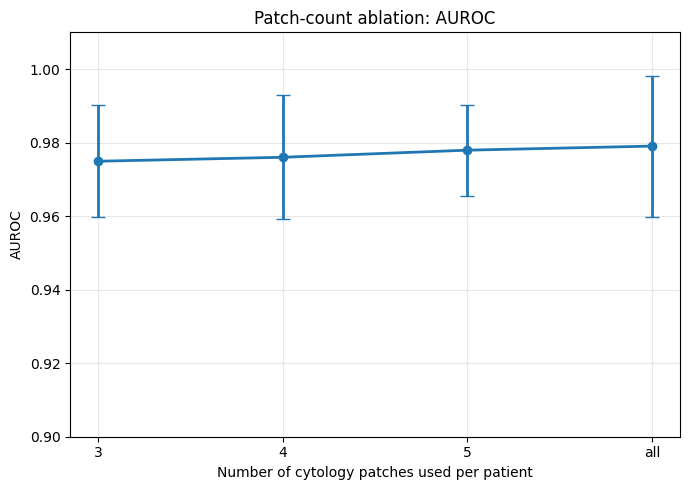

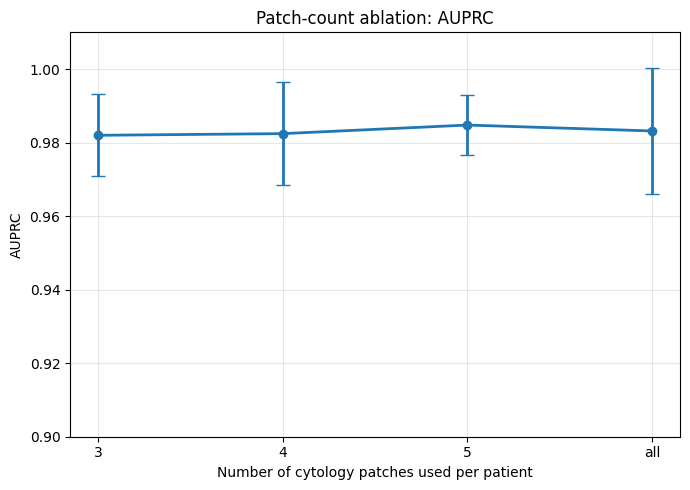

Saved figures:
D:\Thyroid(Laziz)\outputs\pathology_mil_ablation\figures\patch_count_ablation_auroc.png
D:\Thyroid(Laziz)\outputs\pathology_mil_ablation\figures\patch_count_ablation_auroc.pdf
D:\Thyroid(Laziz)\outputs\pathology_mil_ablation\figures\patch_count_ablation_auprc.png
D:\Thyroid(Laziz)\outputs\pathology_mil_ablation\figures\patch_count_ablation_auprc.pdf


In [18]:

# =========================================================
# 17. PLOTS
# =========================================================
def plot_patch_count_ablation(agg):
    labels = agg["bag_size"].tolist()
    x = np.arange(len(labels))

    plt.figure(figsize=(7, 5))
    plt.errorbar(
        x,
        agg["best_val_auroc_mean"],
        yerr=agg["best_val_auroc_std"],
        marker="o",
        capsize=5,
        linewidth=2
    )
    plt.xticks(x, labels)
    plt.xlabel("Number of cytology patches used per patient")
    plt.ylabel("AUROC")
    plt.title("Patch-count ablation: AUROC")
    plt.ylim(0.90, 1.01)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_png = FIG_DIR / "patch_count_ablation_auroc.png"
    out_pdf = FIG_DIR / "patch_count_ablation_auroc.pdf"
    plt.savefig(out_png, dpi=300)
    plt.savefig(out_pdf)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.errorbar(
        x,
        agg["best_val_auprc_mean"],
        yerr=agg["best_val_auprc_std"],
        marker="o",
        capsize=5,
        linewidth=2
    )
    plt.xticks(x, labels)
    plt.xlabel("Number of cytology patches used per patient")
    plt.ylabel("AUPRC")
    plt.title("Patch-count ablation: AUPRC")
    plt.ylim(0.90, 1.01)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_png2 = FIG_DIR / "patch_count_ablation_auprc.png"
    out_pdf2 = FIG_DIR / "patch_count_ablation_auprc.pdf"
    plt.savefig(out_png2, dpi=300)
    plt.savefig(out_pdf2)
    plt.show()

    print("Saved figures:")
    print(out_png)
    print(out_pdf)
    print(out_png2)
    print(out_pdf2)

plot_patch_count_ablation(ablation_summary)



## Next steps after this notebook

After the patch-count ablation finishes, the strongest next analyses are:

1. Statistical significance testing between pathology MIL and gated fusion  
2. Bootstrap 95% confidence intervals  
3. Robustness analysis using noise, blur, brightness, and stain perturbation  
4. MIL attention visualisation for top-attended cytology patches  
5. Error analysis for false positives and false negatives  


In [21]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageFilter, ImageEnhance

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import timm
import matplotlib.pyplot as plt

from torchvision import transforms

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
)

from scipy.stats import wilcoxon, ttest_rel


# =========================================================
# CONFIG
# =========================================================
DATA_ROOT = Path(r"D:\Thyroid(Laziz)")

FOLDS_CSV = DATA_ROOT / "outputs" / "folds" / "strict_multimodal_5folds_windows.csv"

PATH_MIL_LOG_DIR = DATA_ROOT / "outputs" / "pathology_mil_baseline" / "logs"
GATED_LOG_DIR = DATA_ROOT / "outputs" / "multimodal_gated_baseline" / "logs"

ABLATION_DIR = DATA_ROOT / "outputs" / "pathology_mil_ablation"
ABLATION_LOG_DIR = ABLATION_DIR / "logs"
ABLATION_CKPT_DIR = ABLATION_DIR / "checkpoints"

OUT_DIR = DATA_ROOT / "outputs" / "posthoc_analysis"
ROBUST_DIR = OUT_DIR / "robustness"
ATTN_DIR = OUT_DIR / "attention_visualisations"
STATS_DIR = OUT_DIR / "statistics"

OUT_DIR.mkdir(parents=True, exist_ok=True)
ROBUST_DIR.mkdir(parents=True, exist_ok=True)
ATTN_DIR.mkdir(parents=True, exist_ok=True)
STATS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0
MODEL_NAME = "resnet18"
FOLDS = [0, 1, 2, 3, 4]

# Use all-patch pathology MIL for robustness + attention
BAG_TAG = "all"

RANDOM_SEED = 42
N_BOOTSTRAP = 2000


# =========================================================
# SEED
# =========================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(RANDOM_SEED)


# =========================================================
# BASIC METRICS
# =========================================================
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sens = tp / (tp + fn) if tp + fn > 0 else 0
    spec = tn / (tn + fp) if tn + fp > 0 else 0

    return {
        "auroc": auroc,
        "auprc": auprc,
        "accuracy": acc,
        "f1": f1,
        "mcc": mcc,
        "sensitivity": sens,
        "specificity": spec,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


# =========================================================
# STATISTICAL TESTING
# =========================================================
def load_summary_csvs():
    path_summary = PATH_MIL_LOG_DIR / "five_fold_summary_resnet18_attnmil.csv"
    gated_summary = GATED_LOG_DIR / "five_fold_summary_multimodal_gated.csv"

    if not path_summary.exists():
        raise FileNotFoundError(path_summary)
    if not gated_summary.exists():
        raise FileNotFoundError(gated_summary)

    path_df = pd.read_csv(path_summary)
    gated_df = pd.read_csv(gated_summary)

    return path_df, gated_df


def paired_tests():
    print("\n" + "=" * 80)
    print("STATISTICAL TESTING: PATHOLOGY MIL vs MULTIMODAL GATED")
    print("=" * 80)

    path_df, gated_df = load_summary_csvs()

    metrics = [
        "best_val_auroc",
        "best_val_auprc",
        "best_val_accuracy",
        "best_val_f1",
        "best_val_mcc",
        "best_val_sensitivity",
        "best_val_specificity",
    ]

    rows = []

    for metric in metrics:
        x = path_df.sort_values("fold")[metric].values
        y = gated_df.sort_values("fold")[metric].values
        diff = y - x

        try:
            w_stat, w_p = wilcoxon(y, x)
        except Exception:
            w_stat, w_p = np.nan, np.nan

        try:
            t_stat, t_p = ttest_rel(y, x)
        except Exception:
            t_stat, t_p = np.nan, np.nan

        rows.append({
            "metric": metric,
            "pathology_mil_mean": float(np.mean(x)),
            "gated_mean": float(np.mean(y)),
            "mean_difference_gated_minus_pathology": float(np.mean(diff)),
            "std_difference": float(np.std(diff, ddof=1)),
            "wilcoxon_stat": float(w_stat) if not np.isnan(w_stat) else np.nan,
            "wilcoxon_p": float(w_p) if not np.isnan(w_p) else np.nan,
            "paired_t_stat": float(t_stat) if not np.isnan(t_stat) else np.nan,
            "paired_t_p": float(t_p) if not np.isnan(t_p) else np.nan,
        })

    out = pd.DataFrame(rows)
    out.to_csv(STATS_DIR / "paired_statistical_tests_pathology_vs_gated.csv", index=False)

    print(out.to_string(index=False))
    return out


def load_oof_predictions(model):
    if model == "pathology":
        log_dir = PATH_MIL_LOG_DIR
        pattern = "best_val_predictions_fold{}_resnet18_attnmil.csv"
    elif model == "gated":
        log_dir = GATED_LOG_DIR
        pattern = "best_val_predictions_fold{}_multimodal_gated.csv"
    else:
        raise ValueError(model)

    rows = []

    for fold in FOLDS:
        p = log_dir / pattern.format(fold)
        if not p.exists():
            raise FileNotFoundError(p)
        df = pd.read_csv(p)
        df["fold"] = fold
        df["model"] = model
        rows.append(df)

    return pd.concat(rows, ignore_index=True)


def bootstrap_ci_oof():
    print("\n" + "=" * 80)
    print("BOOTSTRAP 95% CI ON OUT-OF-FOLD PREDICTIONS")
    print("=" * 80)

    path_pred = load_oof_predictions("pathology")
    gated_pred = load_oof_predictions("gated")

    merged = path_pred[["patient_id", "y_true", "y_prob"]].merge(
        gated_pred[["patient_id", "y_prob"]],
        on="patient_id",
        suffixes=("_pathology", "_gated")
    )

    y = merged["y_true"].values
    p_path = merged["y_prob_pathology"].values
    p_gated = merged["y_prob_gated"].values

    rng = np.random.default_rng(RANDOM_SEED)
    n = len(merged)

    boot_rows = []

    for _ in range(N_BOOTSTRAP):
        idx = rng.integers(0, n, n)

        y_b = y[idx]

        # skip bootstrap samples with one class only
        if len(np.unique(y_b)) < 2:
            continue

        path_auc = roc_auc_score(y_b, p_path[idx])
        gated_auc = roc_auc_score(y_b, p_gated[idx])

        path_ap = average_precision_score(y_b, p_path[idx])
        gated_ap = average_precision_score(y_b, p_gated[idx])

        boot_rows.append({
            "pathology_auroc": path_auc,
            "gated_auroc": gated_auc,
            "diff_auroc_gated_minus_pathology": gated_auc - path_auc,
            "pathology_auprc": path_ap,
            "gated_auprc": gated_ap,
            "diff_auprc_gated_minus_pathology": gated_ap - path_ap,
        })

    boot = pd.DataFrame(boot_rows)
    boot.to_csv(STATS_DIR / "bootstrap_oof_results.csv", index=False)

    summary = []

    for col in boot.columns:
        summary.append({
            "metric": col,
            "mean": float(boot[col].mean()),
            "ci_lower_2_5": float(boot[col].quantile(0.025)),
            "ci_upper_97_5": float(boot[col].quantile(0.975)),
        })

    summary_df = pd.DataFrame(summary)
    summary_df.to_csv(STATS_DIR / "bootstrap_oof_95ci_summary.csv", index=False)

    print(summary_df.to_string(index=False))
    return summary_df


# =========================================================
# DATASET FOR ROBUSTNESS AND ATTENTION
# =========================================================
def pil_loader(path):
    return Image.open(path).convert("RGB")


def parse_json_list(x):
    if isinstance(x, list):
        return x
    return json.loads(x)


def perturb_image(img, perturbation):
    if perturbation == "clean":
        return img

    if perturbation == "gaussian_noise":
        arr = np.asarray(img).astype(np.float32)
        noise = np.random.normal(0, 12, arr.shape)
        arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
        return Image.fromarray(arr)

    if perturbation == "blur":
        return img.filter(ImageFilter.GaussianBlur(radius=1.2))

    if perturbation == "brightness_low":
        return ImageEnhance.Brightness(img).enhance(0.75)

    if perturbation == "brightness_high":
        return ImageEnhance.Brightness(img).enhance(1.25)

    if perturbation == "contrast_low":
        return ImageEnhance.Contrast(img).enhance(0.75)

    if perturbation == "contrast_high":
        return ImageEnhance.Contrast(img).enhance(1.25)

    raise ValueError(f"Unknown perturbation: {perturbation}")


def val_transform(img_size=224):
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])


class PathologyEvalDataset(Dataset):
    def __init__(self, fold, perturbation="clean", bag_size=None):
        self.df = pd.read_csv(FOLDS_CSV)
        self.df = self.df[self.df["fold"] == fold].reset_index(drop=True)
        self.perturbation = perturbation
        self.bag_size = bag_size
        self.transform = val_transform(IMG_SIZE)

    def __len__(self):
        return len(self.df)

    def choose_paths(self, paths):
        if self.bag_size is None:
            return paths

        if len(paths) >= self.bag_size:
            return paths[:self.bag_size]

        chosen = paths.copy()
        while len(chosen) < self.bag_size:
            chosen.append(paths[len(chosen) % len(paths)])
        return chosen

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        paths = parse_json_list(row["pathology_patch_paths_json"])
        paths = self.choose_paths(paths)

        bag = []
        for p in paths:
            img = pil_loader(p)
            img = perturb_image(img, self.perturbation)
            img = self.transform(img)
            bag.append(img)

        bag = torch.stack(bag, dim=0)

        return {
            "bag": bag,
            "label": torch.tensor(int(row["label"]), dtype=torch.float32),
            "patient_id": row["patient_id"],
            "patch_paths": paths,
        }


def pathology_collate_with_paths(batch):
    labels = torch.stack([x["label"] for x in batch], dim=0)
    patient_ids = [x["patient_id"] for x in batch]
    patch_paths = [x["patch_paths"] for x in batch]

    lengths = torch.tensor([x["bag"].shape[0] for x in batch], dtype=torch.long)
    max_len = int(lengths.max())

    c, h, w = batch[0]["bag"].shape[1:]

    bags = []
    masks = []

    for x in batch:
        bag = x["bag"]
        n = bag.shape[0]

        if n < max_len:
            pad = torch.zeros((max_len - n, c, h, w), dtype=bag.dtype)
            bag = torch.cat([bag, pad], dim=0)

        mask = torch.zeros(max_len, dtype=torch.bool)
        mask[:n] = True

        bags.append(bag)
        masks.append(mask)

    return {
        "bag": torch.stack(bags, dim=0),
        "bag_mask": torch.stack(masks, dim=0),
        "label": labels,
        "patient_id": patient_ids,
        "patch_paths": patch_paths,
    }


# =========================================================
# MODEL
# =========================================================
class PatchEncoder(nn.Module):
    def __init__(self, model_name="resnet18", pretrained=False, feat_dim=256):
        super().__init__()

        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,
            global_pool="avg",
        )

        in_dim = self.backbone.num_features

        self.proj = nn.Sequential(
            nn.Linear(in_dim, feat_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
        )

    def forward(self, x):
        return self.proj(self.backbone(x))


class AttentionMIL(nn.Module):
    def __init__(self, model_name="resnet18", pretrained=False, feat_dim=256, attn_dim=128):
        super().__init__()

        self.encoder = PatchEncoder(model_name, pretrained, feat_dim)

        self.attn_v = nn.Linear(feat_dim, attn_dim)
        self.attn_u = nn.Linear(feat_dim, attn_dim)
        self.attn_w = nn.Linear(attn_dim, 1)

        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(128, 1),
        )

    def forward(self, bag, bag_mask):
        b, n, c, h, w = bag.shape

        flat = bag.view(b * n, c, h, w)
        feat = self.encoder(flat)

        d = feat.shape[-1]
        feat = feat.view(b, n, d)

        av = torch.tanh(self.attn_v(feat))
        au = torch.sigmoid(self.attn_u(feat))
        a = self.attn_w(av * au).squeeze(-1)

        a = a.masked_fill(~bag_mask, float("-inf"))
        attn = torch.softmax(a, dim=1)

        bag_feat = torch.sum(attn.unsqueeze(-1) * feat, dim=1)
        logits = self.classifier(bag_feat).squeeze(-1)

        return logits, attn


def load_model_for_fold(fold, bag_tag=BAG_TAG):
    ckpt_path = ABLATION_CKPT_DIR / f"best_fold{fold}_{MODEL_NAME}_attnmil_{bag_tag}.pt"

    if not ckpt_path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {ckpt_path}")

    model = AttentionMIL(MODEL_NAME, pretrained=False).to(DEVICE)
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    return model


# =========================================================
# ROBUSTNESS ANALYSIS
# =========================================================
@torch.no_grad()
def evaluate_fold_robustness(fold, perturbation):
    model = load_model_for_fold(fold, BAG_TAG)

    ds = PathologyEvalDataset(
        fold=fold,
        perturbation=perturbation,
        bag_size=None if BAG_TAG == "all" else int(BAG_TAG.replace("bag", "")),
    )

    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=pathology_collate_with_paths,
    )

    all_probs = []
    all_labels = []
    all_patient_ids = []

    for batch in loader:
        bag = batch["bag"].to(DEVICE)
        mask = batch["bag_mask"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        logits, attn = model(bag, mask)
        probs = torch.sigmoid(logits).detach().cpu().numpy()

        all_probs.extend(probs.tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_patient_ids.extend(batch["patient_id"])

    metrics = compute_metrics(all_labels, all_probs)
    metrics["fold"] = fold
    metrics["perturbation"] = perturbation

    pred_df = pd.DataFrame({
        "fold": fold,
        "perturbation": perturbation,
        "patient_id": all_patient_ids,
        "y_true": [int(x) for x in all_labels],
        "y_prob": [float(x) for x in all_probs],
    })

    return metrics, pred_df


def run_robustness_analysis():
    print("\n" + "=" * 80)
    print("ROBUSTNESS ANALYSIS")
    print("=" * 80)

    perturbations = [
        "clean",
        "gaussian_noise",
        "blur",
        "brightness_low",
        "brightness_high",
        "contrast_low",
        "contrast_high",
    ]

    metric_rows = []
    pred_rows = []

    for perturbation in perturbations:
        for fold in FOLDS:
            print(f"Evaluating fold {fold}, perturbation: {perturbation}")
            metrics, preds = evaluate_fold_robustness(fold, perturbation)
            metric_rows.append(metrics)
            pred_rows.append(preds)

    metrics_df = pd.DataFrame(metric_rows)
    preds_df = pd.concat(pred_rows, ignore_index=True)

    metrics_df.to_csv(ROBUST_DIR / "robustness_fold_metrics.csv", index=False)
    preds_df.to_csv(ROBUST_DIR / "robustness_predictions.csv", index=False)

    agg = metrics_df.groupby("perturbation").agg({
        "auroc": ["mean", "std"],
        "auprc": ["mean", "std"],
        "accuracy": ["mean", "std"],
        "f1": ["mean", "std"],
        "mcc": ["mean", "std"],
        "sensitivity": ["mean", "std"],
        "specificity": ["mean", "std"],
    })

    agg.to_csv(ROBUST_DIR / "robustness_summary.csv")

    print(agg)
    return metrics_df, agg


# =========================================================
# ATTENTION VISUALISATION
# =========================================================
# =========================================================
# ATTENTION VISUALISATION
# =========================================================
@torch.no_grad()
def collect_attention_cases(fold, max_cases=8):
    model = load_model_for_fold(fold, BAG_TAG)

    ds = PathologyEvalDataset(
        fold=fold,
        perturbation="clean",
        bag_size=None if BAG_TAG == "all" else int(BAG_TAG.replace("bag", ""))
    )

    loader = DataLoader(
        ds,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        collate_fn=pathology_collate_with_paths,
    )

    rows = []

    for batch in loader:
        bag = batch["bag"].to(DEVICE)
        mask = batch["bag_mask"].to(DEVICE)

        label = int(batch["label"].item())
        patient_id = batch["patient_id"][0]
        patch_paths = batch["patch_paths"][0]

        logits, attn = model(bag, mask)

        prob = float(torch.sigmoid(logits).detach().cpu().item())
        pred = int(prob >= 0.5)

        attn_scores = attn.detach().cpu().numpy()[0]
        attn_scores = attn_scores[:len(patch_paths)]

        for i, p in enumerate(patch_paths):
            rows.append({
                "fold": fold,
                "patient_id": patient_id,
                "label": label,
                "prediction": pred,
                "probability": prob,
                "patch_index": i,
                "patch_path": p,
                "attention_score": float(attn_scores[i]),
                "correct": int(label == pred),
            })

    df = pd.DataFrame(rows)

    patient_df = (
        df.groupby(
            ["fold", "patient_id", "label", "prediction", "probability", "correct"],
            as_index=False
        )["attention_score"]
        .max()
    )

    selected = []

    conditions = [
        ("TP", (patient_df["label"] == 1) & (patient_df["prediction"] == 1)),
        ("TN", (patient_df["label"] == 0) & (patient_df["prediction"] == 0)),
        ("FP", (patient_df["label"] == 0) & (patient_df["prediction"] == 1)),
        ("FN", (patient_df["label"] == 1) & (patient_df["prediction"] == 0)),
    ]

    for case_type, cond in conditions:
        sub = patient_df[cond].copy()

        if len(sub) > 0:
            sub["case_type"] = case_type
            selected.append(sub.head(max_cases // 4 + 1))

    if len(selected) > 0:
        selected_df = pd.concat(selected, ignore_index=True).head(max_cases)
    else:
        selected_df = pd.DataFrame(columns=[
            "fold", "patient_id", "label", "prediction",
            "probability", "correct", "attention_score", "case_type"
        ])

    return df, selected_df


def make_attention_panel(patient_patch_df, case_type, out_path, top_k=5):
    patient_id = patient_patch_df["patient_id"].iloc[0]
    label = int(patient_patch_df["label"].iloc[0])
    prob = float(patient_patch_df["probability"].iloc[0])

    top = patient_patch_df.sort_values(
        "attention_score",
        ascending=False
    ).head(top_k)

    n = len(top)

    plt.figure(figsize=(3 * n, 4))

    for idx, (_, row) in enumerate(top.iterrows()):
        img = Image.open(row["patch_path"]).convert("RGB")

        plt.subplot(1, n, idx + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"Attn={row['attention_score']:.3f}\nPatch {row['patch_index']}",
            fontsize=9
        )

    label_name = "PTC" if label == 1 else "Benign"

    plt.suptitle(
        f"{case_type} | {patient_id} | True={label_name} | P(PTC)={prob:.3f}",
        fontsize=12
    )

    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.close()


def run_attention_visualisation():
    print("\n" + "=" * 80)
    print("MIL ATTENTION VISUALISATION")
    print("=" * 80)

    all_attn = []
    all_selected = []

    for fold in FOLDS:
        print(f"Collecting attention for fold {fold}")

        attn_df, selected_df = collect_attention_cases(
            fold=fold,
            max_cases=8
        )

        all_attn.append(attn_df)

        if len(selected_df) > 0:
            all_selected.append(selected_df)

    attn_all = pd.concat(all_attn, ignore_index=True)

    if len(all_selected) > 0:
        selected_all = pd.concat(all_selected, ignore_index=True)
    else:
        selected_all = pd.DataFrame()

    attn_all.to_csv(
        ATTN_DIR / "all_patch_attention_scores.csv",
        index=False
    )

    selected_all.to_csv(
        ATTN_DIR / "selected_attention_cases.csv",
        index=False
    )

    if len(selected_all) == 0:
        print("No selected cases found.")
        return attn_all, selected_all

    for _, case in selected_all.iterrows():
        patient_id = case["patient_id"]
        fold = int(case["fold"])
        case_type = case["case_type"]

        patient_patch_df = attn_all[
            (attn_all["patient_id"] == patient_id) &
            (attn_all["fold"] == fold)
        ].copy()

        if len(patient_patch_df) == 0:
            continue

        out_path = ATTN_DIR / f"attention_{case_type}_fold{fold}_{patient_id}.png"

        make_attention_panel(
            patient_patch_df=patient_patch_df,
            case_type=case_type,
            out_path=out_path,
            top_k=5
        )

    print(f"Saved attention outputs to: {ATTN_DIR}")
    return attn_all, selected_all

# =========================================================
# MAIN
# =========================================================
def main():
    print("Device:", DEVICE)
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))

    paired_tests()
    bootstrap_ci_oof()
    run_robustness_analysis()
    run_attention_visualisation()

    print("\nDONE.")
    print(f"Outputs saved to: {OUT_DIR}")


if __name__ == "__main__":
    main()

Device: cuda
GPU: NVIDIA GeForce RTX 4060

STATISTICAL TESTING: PATHOLOGY MIL vs MULTIMODAL GATED
              metric  pathology_mil_mean  gated_mean  mean_difference_gated_minus_pathology  std_difference  wilcoxon_stat  wilcoxon_p  paired_t_stat  paired_t_p
      best_val_auroc            0.984097    0.983674                              -0.000422        0.005445            7.0    1.000000      -0.173466    0.870709
      best_val_auprc            0.988358    0.989221                               0.000863        0.001915            4.0    0.437500       1.007275    0.370789
   best_val_accuracy            0.940207    0.929322                              -0.010885        0.017705            1.5    0.197466      -1.374695    0.241209
         best_val_f1            0.949137    0.940363                              -0.008774        0.014176            3.0    0.312500      -1.383939    0.238588
        best_val_mcc            0.879283    0.858409                              -0.020875 

C:\Users\admin\miniconda3\lib\site-packages\scipy\stats\_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


                          metric      mean  ci_lower_2_5  ci_upper_97_5
                 pathology_auroc  0.980412      0.967135       0.990859
                     gated_auroc  0.979084      0.963129       0.991243
diff_auroc_gated_minus_pathology -0.001328     -0.011876       0.008134
                 pathology_auprc  0.985485      0.974423       0.993732
                     gated_auprc  0.985987      0.975484       0.993849
diff_auprc_gated_minus_pathology  0.000502     -0.007245       0.008432

ROBUSTNESS ANALYSIS
Evaluating fold 0, perturbation: clean


C:\Users\admin\AppData\Local\Temp\ipykernel_14188\1239568845.py:483: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=DEVICE)


Evaluating fold 1, perturbation: clean


...

C:\Users\admin\AppData\Local\Temp\ipykernel_14188\1239568845.py:483: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=DEVICE)


C:\Users\admin\AppData\Local\Temp\ipykernel_14188\1239568845.py:483: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=DEVICE)


C:\Users\admin\AppData\Local\Temp\ipykernel_14188\1239568845.py:483: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=DEVICE)


C:\Users\admin\AppData\Local\Temp\ipykernel_14188\1239568845.py:483: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=DEVICE)


Saved attention outputs to: D:\Thyroid(Laziz)\outputs\posthoc_analysis\attention_visualisations

DONE.
Outputs saved to: D:\Thyroid(Laziz)\outputs\posthoc_analysis


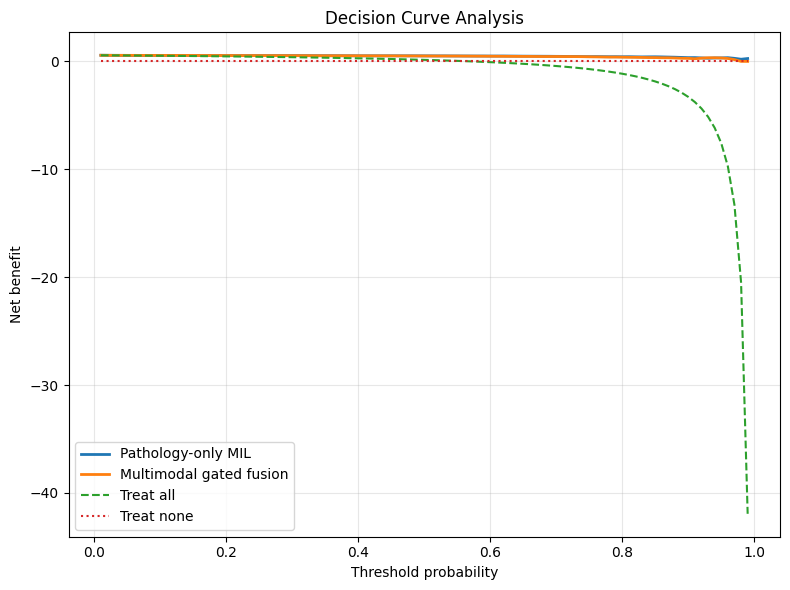

Saved:
D:\Thyroid(Laziz)\outputs\posthoc_analysis\decision_curve_analysis\decision_curve_analysis.csv
D:\Thyroid(Laziz)\outputs\posthoc_analysis\decision_curve_analysis\decision_curve_analysis.png
D:\Thyroid(Laziz)\outputs\posthoc_analysis\decision_curve_analysis\decision_curve_analysis.pdf
   threshold  pathology_mil_net_benefit  gated_fusion_net_benefit  \
0       0.01                   0.566809                  0.566315   
1       0.02                   0.564386                  0.560670   
2       0.03                   0.559362                  0.556645   
3       0.04                   0.557858                  0.557971   
4       0.05                   0.554062                  0.557637   

   treat_all_net_benefit  treat_none_net_benefit  
0               0.566315                     0.0  
1               0.561890                     0.0  
2               0.557373                     0.0  
3               0.552763                     0.0  
4               0.548055              

In [22]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


DATA_ROOT = Path(r"D:\Thyroid(Laziz)")

PATH_MIL_LOG_DIR = DATA_ROOT / "outputs" / "pathology_mil_baseline" / "logs"
GATED_LOG_DIR = DATA_ROOT / "outputs" / "multimodal_gated_baseline" / "logs"

OUT_DIR = DATA_ROOT / "outputs" / "posthoc_analysis" / "decision_curve_analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FOLDS = [0, 1, 2, 3, 4]


def load_predictions(model):
    rows = []

    if model == "pathology":
        log_dir = PATH_MIL_LOG_DIR
        patterns = [
            "best_val_predictions_fold{}_resnet18_attnmil.csv",
            "best_val_predictions_fold{}_resnet18_attnmil_all.csv",
        ]
    elif model == "gated":
        log_dir = GATED_LOG_DIR
        patterns = [
            "best_val_predictions_fold{}_multimodal_gated.csv"
        ]
    else:
        raise ValueError(model)

    for fold in FOLDS:
        found = None

        for pattern in patterns:
            p = log_dir / pattern.format(fold)
            if p.exists():
                found = p
                break

        if found is None:
            raise FileNotFoundError(f"No prediction file found for {model}, fold {fold}")

        df = pd.read_csv(found)
        df["fold"] = fold
        df["model"] = model
        rows.append(df)

    return pd.concat(rows, ignore_index=True)


def net_benefit(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    pred = (y_prob >= threshold).astype(int)

    tp = np.sum((pred == 1) & (y_true == 1))
    fp = np.sum((pred == 1) & (y_true == 0))
    n = len(y_true)

    if threshold >= 1.0:
        return np.nan

    return (tp / n) - (fp / n) * (threshold / (1 - threshold))


def net_benefit_treat_all(y_true, threshold):
    y_true = np.asarray(y_true).astype(int)

    prevalence = np.mean(y_true)

    if threshold >= 1.0:
        return np.nan

    return prevalence - (1 - prevalence) * (threshold / (1 - threshold))


def run_dca():
    path_df = load_predictions("pathology")
    gated_df = load_predictions("gated")

    merged = path_df[["patient_id", "y_true", "y_prob"]].merge(
        gated_df[["patient_id", "y_prob"]],
        on="patient_id",
        suffixes=("_pathology", "_gated")
    )

    merged.to_csv(OUT_DIR / "dca_merged_predictions.csv", index=False)

    y_true = merged["y_true"].values
    p_path = merged["y_prob_pathology"].values
    p_gated = merged["y_prob_gated"].values

    thresholds = np.linspace(0.01, 0.99, 99)

    rows = []

    for t in thresholds:
        rows.append({
            "threshold": t,
            "pathology_mil_net_benefit": net_benefit(y_true, p_path, t),
            "gated_fusion_net_benefit": net_benefit(y_true, p_gated, t),
            "treat_all_net_benefit": net_benefit_treat_all(y_true, t),
            "treat_none_net_benefit": 0.0,
        })

    dca = pd.DataFrame(rows)
    dca.to_csv(OUT_DIR / "decision_curve_analysis.csv", index=False)

    plt.figure(figsize=(8, 6))

    plt.plot(
        dca["threshold"],
        dca["pathology_mil_net_benefit"],
        linewidth=2,
        label="Pathology-only MIL"
    )

    plt.plot(
        dca["threshold"],
        dca["gated_fusion_net_benefit"],
        linewidth=2,
        label="Multimodal gated fusion"
    )

    plt.plot(
        dca["threshold"],
        dca["treat_all_net_benefit"],
        linestyle="--",
        linewidth=1.5,
        label="Treat all"
    )

    plt.plot(
        dca["threshold"],
        dca["treat_none_net_benefit"],
        linestyle=":",
        linewidth=1.5,
        label="Treat none"
    )

    plt.xlabel("Threshold probability")
    plt.ylabel("Net benefit")
    plt.title("Decision Curve Analysis")
    plt.legend(loc="best")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(OUT_DIR / "decision_curve_analysis.png", dpi=300)
    plt.savefig(OUT_DIR / "decision_curve_analysis.pdf")
    plt.show()

    print("Saved:")
    print(OUT_DIR / "decision_curve_analysis.csv")
    print(OUT_DIR / "decision_curve_analysis.png")
    print(OUT_DIR / "decision_curve_analysis.pdf")

    return dca


if __name__ == "__main__":
    dca = run_dca()
    print(dca.head())

In [23]:
from pathlib import Path
import shutil


DATA_ROOT = Path(r"D:\Thyroid(Laziz)")

DEST_DIR = DATA_ROOT / "outputs" / "paper_final" / "figures"
DEST_DIR.mkdir(parents=True, exist_ok=True)


SOURCE_FILES = {
    # Main performance figures
    "Figure_1_ROC_comparison.png": DATA_ROOT / "outputs" / "posthoc_analysis" / "figures" / "oof_roc_pathology_vs_gated.png",
    "Figure_2_PR_comparison.png": DATA_ROOT / "outputs" / "posthoc_analysis" / "figures" / "oof_pr_pathology_vs_gated.png",

    # Calibration
    "Figure_3_Calibration_curve.png": DATA_ROOT / "outputs" / "paper_outputs" / "figure_2_calibration_curve.png",

    # Robustness
    "Figure_4_Robustness_AUROC.png": DATA_ROOT / "outputs" / "posthoc_analysis" / "figures" / "robustness_auroc.png",
    "Figure_5_Robustness_Specificity.png": DATA_ROOT / "outputs" / "posthoc_analysis" / "figures" / "robustness_specificity.png",

    # Decision curve
    "Figure_6_Decision_Curve_Analysis.png": DATA_ROOT / "outputs" / "posthoc_analysis" / "decision_curve_analysis" / "decision_curve_analysis.png",

    # Patch-count ablation
    "Figure_7_Patch_Count_Ablation_AUROC.png": DATA_ROOT / "outputs" / "pathology_mil_ablation" / "figures" / "patch_count_ablation_auroc.png",
    "Figure_8_Patch_Count_Ablation_AUPRC.png": DATA_ROOT / "outputs" / "pathology_mil_ablation" / "figures" / "patch_count_ablation_auprc.png",

    # Attention distribution
    "Figure_9_Attention_Score_Distribution.png": DATA_ROOT / "outputs" / "posthoc_analysis" / "figures" / "attention_score_distribution.png",
}


def copy_file(src: Path, dst: Path):
    if src.exists():
        shutil.copy2(src, dst)
        print(f"Copied: {dst.name}")
    else:
        print(f"Missing: {src}")


def collect_main_figures():
    print("\nCollecting main figures...\n")

    for out_name, src in SOURCE_FILES.items():
        copy_file(src, DEST_DIR / out_name)


def collect_attention_figures():
    print("\nCollecting attention figures...\n")

    attn_dir = DATA_ROOT / "outputs" / "posthoc_analysis" / "attention_visualisations"

    if not attn_dir.exists():
        print(f"Missing attention folder: {attn_dir}")
        return

    attention_files = sorted(attn_dir.glob("attention_*.png"))

    if len(attention_files) == 0:
        print("No attention PNG files found.")
        return

    for i, src in enumerate(attention_files, start=1):
        out_name = f"Figure_10_Attention_Panel_{i:02d}_{src.name}"
        copy_file(src, DEST_DIR / out_name)


def collect_pdf_versions():
    print("\nCollecting PDF versions if available...\n")

    pdf_sources = [
        DATA_ROOT / "outputs" / "posthoc_analysis" / "figures",
        DATA_ROOT / "outputs" / "paper_outputs",
        DATA_ROOT / "outputs" / "posthoc_analysis" / "decision_curve_analysis",
        DATA_ROOT / "outputs" / "pathology_mil_ablation" / "figures",
    ]

    pdf_dest = DEST_DIR / "pdf_versions"
    pdf_dest.mkdir(parents=True, exist_ok=True)

    for folder in pdf_sources:
        if folder.exists():
            for src in folder.glob("*.pdf"):
                copy_file(src, pdf_dest / src.name)


def main():
    collect_main_figures()
    collect_attention_figures()
    collect_pdf_versions()

    print("\nDone.")
    print(f"All figures saved to:\n{DEST_DIR}")


if __name__ == "__main__":
    main()



Missing: D:\Thyroid(Laziz)\outputs\posthoc_analysis\figures\oof_roc_pathology_vs_gated.png
Missing: D:\Thyroid(Laziz)\outputs\posthoc_analysis\figures\oof_pr_pathology_vs_gated.png
Copied: Figure_3_Calibration_curve.png
Missing: D:\Thyroid(Laziz)\outputs\posthoc_analysis\figures\robustness_auroc.png
Missing: D:\Thyroid(Laziz)\outputs\posthoc_analysis\figures\robustness_specificity.png
Copied: Figure_6_Decision_Curve_Analysis.png
Copied: Figure_7_Patch_Count_Ablation_AUROC.png
Copied: Figure_8_Patch_Count_Ablation_AUPRC.png
Missing: D:\Thyroid(Laziz)\outputs\posthoc_analysis\figures\attention_score_distribution.png


Copied: Figure_10_Attention_Panel_01_attention_FN_fold4_ptc_56.png
Copied: Figure_10_Attention_Panel_02_attention_FP_fold0_benign_135.png
Copied: Figure_10_Attention_Panel_03_attention_FP_fold0_benign_49.png
Copied: Figure_10_Attention_Panel_04_attention_FP_fold1_benign_139.png
Copied: Figure_10_Attention_Panel_05_attention_FP_fold1_benign_71.png
Copied: Figure_10_Attenti